# Analytics Project
## Dynamic Pricing and Purchase Prediction - Predicting Order Behaviour in a Mail-Order Pharmacy

### **Group Alpha**

# 1. Introduction

# 2. Business Understanding
## 2.1 Background Information
## 2.2 Business Objective, Risks, and Benefits
## 2.3 Success Criteria and Data Mining Goals
## 2.4 Project Phases and Tools

# 3. Data Understanding
Adding to the foundation of Business Understanding, the Data Understanding phase focuses on identifying, collecting, and analyzing data sets that can help the project. This phase also has four tasks:
1. Collect initial data: Acquire the necessary data and (if necessary) load it into your analysis tool.
2. Describe data: Examine the data and document its surface properties like data format, number of records, or field identities.
3. Explore data: Dig deeper into the data. Query it, visualize it, and identify relationships among the data.
4. Verify data quality: How clean/dirty is the data? Document any quality issues.

## 3.1 Description of the Data

In [53]:
# Core imports for Step 1 pipeline
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

# Reusable paths
DATA_DIR = Path("data")
PROCESSED_DIR = DATA_DIR / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

print("Core imports and paths set up successfully.")

Core imports and paths set up successfully.


In [54]:
# Load source datasets
train_raw_df = pd.read_csv(DATA_DIR / "train.csv", sep="|")
items_raw_df = pd.read_csv(DATA_DIR / "items.csv", sep="|")

# Minimal schema validation for reproducibility
# A fail-fast schema check is a system design principle that immediately halts processing and throws an error when incoming data violates a predefined schema, preventing corrupt data from propagating. It ensures data integrity by catching issues at the earliest interface—such as during file ingestion or API request validation—rather than allowing failures to break downstream systems.
required_train_cols = {"pid", "click", "basket", "order", "price"}
required_items_cols = {"pid", "manufacturer", "rrp"}

missing_train_cols = required_train_cols - set(train_raw_df.columns)
missing_items_cols = required_items_cols - set(items_raw_df.columns)
if missing_train_cols:
    raise ValueError(f"train.csv missing required columns: {sorted(missing_train_cols)}")
if missing_items_cols:
    raise ValueError(f"items.csv missing required columns: {sorted(missing_items_cols)}")

print("Train shape:", train_raw_df.shape)
print("Items shape:", items_raw_df.shape)
print("Unique pids in train:", train_raw_df["pid"].nunique())
print("Unique pids in items:", items_raw_df["pid"].nunique())

Train shape: (2756003, 11)
Items shape: (22035, 11)
Unique pids in train: 21928
Unique pids in items: 22035


Notes on Output: Not all available products (items.csv) are in the training data (train.csv) or in business context, these products were never clicked, added to the basket or bought.
Potential checks to do:
1. Are events overwritten (When a customer clicks and afterwards adds an item to his basket, is the row in the CSV file overwritten or a new row added)?
2. Which prodcuts are not used?

**Static Product Attributes (items.csv)**

In [55]:
# All numbers should be formatted without scientific notation for readability
pd.set_option("display.float_format", lambda x: f"{x:.2f}")
# new line for better readability of large numbers

print(".head() shows the first 10 rows of the item dataset:")
print(items_raw_df.head(10))
print()
print(".info() provides a concise summary of the DataFrame, including data types and non-null counts:")
print(items_raw_df.info())
print()
print(".describe() provides a statistical summary of the DataFrame:")
print(items_raw_df.describe())
print()
print(".isnull().sum() provides the count of null values in each column:")
print(items_raw_df.isnull().sum())
# We calculate the percentage of missing values for each column to understand the extent of missing data:
missing_percent = (items_raw_df.isnull().sum() / len(items_raw_df)) * 100
print(f"Percentage of missing values in each column:")
print(missing_percent)
print()
print(".value_counts() shows the frequency of unique values in the 'manufacturer' column:")
print(items_raw_df["manufacturer"].value_counts())

.head() shows the first 10 rows of the item dataset:
   pid  manufacturer     group content unit pharmForm  genericProduct  \
0    1             1      2FOI      80   ST       TAB               0   
1    2             1      2FOI      80   ST       Tab               0   
2    3             1      2FOI      10    G       GLO               0   
3    4             1      2FOI      80   ST       TAB               0   
4    5             2  10OJ03JS       8   ST       PUL               0   
5    6             1      2FOI      10    G       GLO               0   
6    7             3     21OKG      15   ST       TRA               0   
7    8             1      2FOI      80   ST       TAB               0   
8    9             1      2FOI      10    G       GLO               0   
9   10             4    12OS2F      30   ST       FTA               0   

   salesIndex  category campaignIndex   rrp  
0          40       NaN           NaN 10.89  
1          40       NaN           NaN 10.89  
2    

**Time-Varying Transactional Data (train.csv)**

In [56]:
# All numbers should be formatted without scientific notation for readability
pd.set_option("display.float_format", lambda x: f"{x:.2f}")
# new line for better readability of large numbers

print(".head() shows the first 10 rows of the train dataset:")
print(train_raw_df.head(10))
print()
print(".info() provides a concise summary of the DataFrame, including data types and non-null counts:")
print(train_raw_df.info())
print()
print(".describe() provides a statistical summary of the DataFrame:")
print(train_raw_df.describe())
print()
print(".isnull().sum() provides the count of null values in each column:")
print(train_raw_df.isnull().sum())
print()
# Calculating the percentage of missing values for each column to understand the extent of missing data:
missing_percent_train = (train_raw_df.isnull().sum() / len(train_raw_df)) * 100
print(f"Percentage of missing values in each column:")
print(missing_percent_train)
print(".click.value_counts() shows the count of each unique value in the 'click' column:")
print(train_raw_df["click"].value_counts())
print()
print(".basket.value_counts() shows the count of each unique value in the 'basket' column:")
print(train_raw_df["basket"].value_counts())
print()
print(".order.value_counts() shows the count of each unique value in the 'order' column:")
print(train_raw_df["order"].value_counts())
print()
print(".price.describe() provides a statistical summary of the 'price' column:")
print(train_raw_df["price"].describe())

.head() shows the first 10 rows of the train dataset:
   lineID  day    pid  adFlag  availability  competitorPrice  click  basket  \
0       1    1   6570       0             2            14.60      1       0   
1       2    1  14922       1             1             8.57      0       1   
2       3    1  16382       0             1            14.77      0       1   
3       4    1   1145       1             1             6.59      0       0   
4       5    1   3394       0             1             4.39      0       0   
5       6    1   3661       0             1            13.66      0       0   
6       7    1   3856       1             1             3.03      0       0   
7       8    1  16963       0             1             8.78      1       0   
8       9    1  14560       0             1            10.84      1       0   
9      10    1   4853       1             1             9.12      1       0   

   order  price  revenue  
0      0  16.89     0.00  
1      0   8.75     0.

## 3.2 Further Data Understanding

**PID Key Integrity Checks**

In [57]:
# Null and duplicate checks for join key pid
train_pid_null_count = int(train_raw_df["pid"].isna().sum())
items_pid_null_count = int(items_raw_df["pid"].isna().sum())

if train_pid_null_count > 0:
    raise ValueError(f"train.csv has {train_pid_null_count} null pid values")

if items_pid_null_count > 0:
    raise ValueError(f"items.csv has {items_pid_null_count} null pid values")

duplicate_pid_count = int(items_raw_df["pid"].duplicated().sum())
if duplicate_pid_count > 0:
    raise ValueError(
        f"items.csv contains {duplicate_pid_count} duplicated pid values; expected unique pid for m:1 merge"
    )

print("All schema and data integrity checks passed successfully.")

All schema and data integrity checks passed successfully.


**Merge Dataset train.csv and items.csv**

In [58]:
# Left join on pid to enrich train data with item attributes
# Learning: validate="m:1" enforces that each pid in train_raw_df matches at most one pid in items_raw_df, ensuring no unintended duplication of rows.
train_item_set = train_raw_df.merge(items_raw_df, on="pid", how="left", validate="m:1")

print("Successfully merged train and items datasets.")

Successfully merged train and items datasets.


**Validation Checks after Merge**

In [59]:
# Validation checks: row/column counts, missing values, and mutual exclusivity of click/basket/order
# Learning: isna vs isnull - both methods are equivalent for pandas DataFrames; isna is an alias for isnull. Using isna() for consistency with pandas documentation and readability.
row_count = int(train_item_set.shape[0])
column_count = int(train_item_set.shape[1])
missing_values = train_item_set.isna().sum().sort_values(ascending=False)

# Strict mutual exclusivity: exactly one of click/basket/order must be 1
action_cols = ["click", "basket", "order"]
action_sum = train_item_set[action_cols].sum(axis=1)
mutual_exclusive_exact = bool((action_sum == 1).all())
violating_rows = int((action_sum != 1).sum())

# Expected parity values from Step 1 baseline
expected = {
    "row_count": 2756003,
    "column_count": 21,
    "mutual_exclusive_exact": True,
}
parity_ok = (
    row_count == expected["row_count"]
    and column_count == expected["column_count"]
    and mutual_exclusive_exact == expected["mutual_exclusive_exact"]
)
if not parity_ok:
    raise AssertionError(
        "Parity check failed. Review source data and merge logic before continuing."
    )

# Persist canonical Step 1 artifacts
merged_out = PROCESSED_DIR / "step1_merged_baseline.csv"
missing_out = PROCESSED_DIR / "step1_missing_values.csv"
summary_out = PROCESSED_DIR / "step1_validation_summary.json"

# Control large-file rewrites explicitly
FORCE_REFRESH_BASELINE = False

# Keep missing report compact but always write a stable CSV schema
missing_report = (
    missing_values[missing_values > 0]
    .rename_axis("column")
    .reset_index(name="missing_count")
)
if missing_report.empty:
    missing_report = pd.DataFrame({"column": [], "missing_count": []})
missing_report.to_csv(missing_out, index=False)

# Write merged baseline only on first run, unless refresh is requested
if FORCE_REFRESH_BASELINE or not merged_out.exists():
    train_item_set.to_csv(merged_out, index=False)

summary_payload = {
    "row_count": row_count,
    "column_count": column_count,
    "mutual_exclusive_exact": mutual_exclusive_exact,
    "violating_rows": violating_rows,
    "parity_ok": parity_ok,
    "expected": expected,
    "generated_at_utc": pd.Timestamp.utcnow().isoformat(),
    "artifacts": {
        "merged": str(merged_out),
        "missing_values": str(missing_out),
        "summary": str(summary_out),
    },
}

with summary_out.open("w", encoding="utf-8") as f:
    json.dump(summary_payload, f, indent=2, sort_keys=True)

print("Row count:", row_count)
print("Column count:", column_count)
print("Rows violating action exclusivity:", violating_rows)
print("Click/basket/order mutual exclusivity (exactly one):", mutual_exclusive_exact)
print("Step 1 parity with baseline:", parity_ok)
print("\nTop missing values:")
print(missing_values.head(10))
print("\nValidation summary:")
print(json.dumps(summary_payload, indent=2))

Row count: 2756003
Column count: 21
Rows violating action exclusivity: 0
Click/basket/order mutual exclusivity (exactly one): True
Step 1 parity with baseline: True

Top missing values:
campaignIndex      2287968
pharmForm           194124
competitorPrice     100687
category             87394
lineID                   0
availability             0
adFlag                   0
pid                      0
day                      0
price                    0
dtype: int64

Validation summary:
{
  "row_count": 2756003,
  "column_count": 21,
  "mutual_exclusive_exact": true,
  "violating_rows": 0,
  "parity_ok": true,
  "expected": {
    "row_count": 2756003,
    "column_count": 21,
    "mutual_exclusive_exact": true
  },
  "generated_at_utc": "2026-04-10T21:40:39.518450+00:00",
  "artifacts": {
    "merged": "data/processed/step1_merged_baseline.csv",
    "missing_values": "data/processed/step1_missing_values.csv",
    "summary": "data/processed/step1_validation_summary.json"
  }
}


/var/folders/3p/m3yt82xn6wn0mbp1wnz1p19c0000gn/T/ipykernel_22160/2428946334.py:58: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  "generated_at_utc": pd.Timestamp.utcnow().isoformat(),


**Exploration of the target variable 'order'**

Distribution of the target variable 'order':
order
0    2050913
1     705090
Name: count, dtype: int64

Percentage distribution of 'order':
order
0   74.42
1   25.58
Name: count, dtype: float64

Class imbalance summary:
Majority class: 0 (2,050,913)
Minority class: 1 (705,090)
Imbalance ratio (majority/minority): 2.91:1
No-order rate: 74.42% | Order rate: 25.58%
Majority-class baseline accuracy: 0.7442
Saved figure to: /Users/annageiser/Documents/GitHub/analytics-project/figures/order_distribution.png


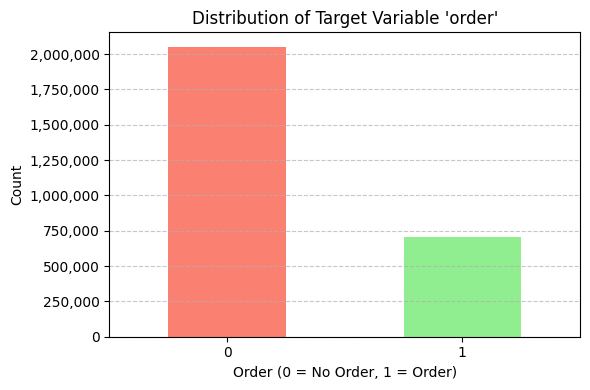

PosixPath('figures/order_distribution.png')

In [ ]:
# Show statistical representation of all numbers in the DataFrame without scientific notation for better readability
pd.set_option("display.float_format", lambda x: f"{x:.2f}")

# Exploration of the target variable ‘order’
print("Distribution of the target variable 'order':")
order_counts = train_raw_df["order"].value_counts()
print(order_counts)
print()
print("Percentage distribution of 'order':")
order_percent = (order_counts / len(train_raw_df)) * 100
print(order_percent)

# Explicit imbalance metrics
majority_count = int(order_counts.max())
minority_count = int(order_counts.min())
majority_class = int(order_counts.idxmax())
minority_class = int(order_counts.idxmin())

imbalance_ratio = majority_count / minority_count
order_rate_pct = float(order_percent.get(1, 0.0))
no_order_rate_pct = float(order_percent.get(0, 0.0))
baseline_majority_accuracy = max(order_percent) / 100

print()
print("Class imbalance summary:")
print(f"Majority class: {majority_class} ({majority_count:,})")
print(f"Minority class: {minority_class} ({minority_count:,})")
print(f"Imbalance ratio (majority/minority): {imbalance_ratio:.2f}:1")
print(f"No-order rate: {no_order_rate_pct:.2f}% | Order rate: {order_rate_pct:.2f}%")
print(f"Majority-class baseline accuracy: {baseline_majority_accuracy:.4f}")

# Plot
fig, ax = plt.subplots(figsize=(6, 4))
order_counts.plot(kind="bar", color=["salmon", "lightgreen"], ax=ax)
ax.set_title("Distribution of Target Variable 'order'")
ax.set_xlabel("Order (0 = No Order, 1 = Order)")
ax.set_ylabel("Count")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.tick_params(axis="x", rotation=0)
ax.grid(axis="y", linestyle="--", alpha=0.7)

FIGURES_DIR = Path("figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

def save_and_show(fig, filename: str, dpi: int = 300) -> Path:
    out_path = FIGURES_DIR / filename
    fig.tight_layout()
    fig.savefig(out_path, dpi=dpi, bbox_inches="tight")
    if not out_path.exists():
        raise FileNotFoundError(f"Figure was not saved: {out_path}")
    print(f"Saved figure to: {out_path.resolve()}")
    plt.show()
    plt.close(fig)
    return out_path

save_and_show(fig, "order_distribution.png")

**Funnel Analysis**

=== Funnel Counts and Rates ===
 stage   count  rate_percent  from_prev_ratio  drop_from_prev_percent
 click 1582827         57.43              NaN                     NaN
basket  468086         16.98             0.30                   70.43
 order  705090         25.58             1.51                  -50.63

=== Funnel Ratios ===
basket/click: 0.2957
order/basket: 1.5063
order/click: 0.4455

mutual_exclusivity_exact: True
NOTE: Stages are mutually exclusive per row; ratios above are event-share ratios, not true user journey conversion rates.
Saved figure to: /Users/annageiser/Documents/GitHub/analytics-project/figures/funnel_click_basket_order.png


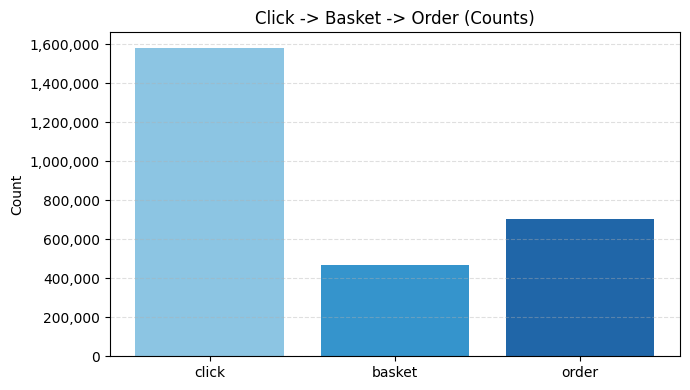

PosixPath('figures/funnel_click_basket_order.png')

In [75]:
# Funnel analysis: click -> basket -> order
stage_cols = ["click", "basket", "order"]

missing = [c for c in stage_cols if c not in train_raw_df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

# Counts and rates by stage
stage_counts = train_raw_df[stage_cols].sum().astype(int)
total_rows = len(train_raw_df)
stage_rates = (stage_counts / total_rows * 100).round(2)

# Build funnel table
funnel_df = pd.DataFrame({
    "stage": stage_cols,
    "count": stage_counts.reindex(stage_cols).values,
    "rate_percent": stage_rates.reindex(stage_cols).values
})

# Sequential ratios (pseudo-funnel on event shares)
funnel_df["from_prev_ratio"] = funnel_df["count"] / funnel_df["count"].shift(1)
funnel_df["drop_from_prev_percent"] = (1 - funnel_df["from_prev_ratio"]) * 100
funnel_df.loc[0, ["from_prev_ratio", "drop_from_prev_percent"]] = pd.NA

# Key ratios
click_to_basket = stage_counts["basket"] / stage_counts["click"]
basket_to_order = stage_counts["order"] / stage_counts["basket"]
click_to_order = stage_counts["order"] / stage_counts["click"]

# Data-contract check: are click/basket/order mutually exclusive per row?
exclusivity_ok = (train_raw_df[stage_cols].sum(axis=1) == 1).all()

print("=== Funnel Counts and Rates ===")
print(funnel_df.to_string(index=False))
print()
print("=== Funnel Ratios ===")
print(f"basket/click: {click_to_basket:.4f}")
print(f"order/basket: {basket_to_order:.4f}")
print(f"order/click: {click_to_order:.4f}")
print()
print(f"mutual_exclusivity_exact: {exclusivity_ok}")

if exclusivity_ok:
    print("NOTE: Stages are mutually exclusive per row; ratios above are event-share ratios, not true user journey conversion rates.")

# Optional visualization
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(funnel_df["stage"], funnel_df["count"], color=["#8cc5e3", "#3594cc", "#2066a8"])
ax.set_title("Click -> Basket -> Order (Counts)")
ax.set_ylabel("Count")
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
save_and_show(fig, "funnel_click_basket_order.png")